# 04 — Evaluation: SHAP, Business Impact & Final Report

This notebook covers Stage 7 of the pipeline — SHAP explanations for individual predictions, global feature importance, and the business cost frame that justifies threshold selection.

In [2]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from features import engineer_features, FEATURE_COLUMNS
from model import ModelConfig, train, evaluate, sweep_thresholds, select_threshold
from explain import build_explainer, get_shap_values, top_k_features, plot_shap_summary

df_raw = pd.read_csv("../data/creditcard.csv")
df     = engineer_features(df_raw)
feature_cols = [c for c in FEATURE_COLUMNS if c in df.columns]
X = df[feature_cols]
y = df["Class"]


c:\Users\DELL\Downloads\credit-card-fraud-detection\credit-card-fraud-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Retrain model (or load from outputs/)

In [4]:
from pathlib import Path

MODEL_DIR = Path("../outputs/model")

try:
    from model import load_model
    model, threshold_cfg = load_model(MODEL_DIR)
    print(f"Loaded model from {MODEL_DIR}")
    print(f"Threshold config: {threshold_cfg}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    THRESHOLD = threshold_cfg["threshold"]

except Exception as e:
    print(f"Model not found ({e}) — retraining…")
    from imblearn.over_sampling import SMOTE

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    try:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except ImportError:
        pass

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.10, random_state=42, stratify=y_train
    )
    config = ModelConfig(n_estimators=300, max_depth=6, learning_rate=0.05,
                         eval_metric="aucpr", early_stopping_rounds=20)
    model = train(X_tr, y_tr, X_val, y_val, config=config, balanced=True)
    sweep_df = sweep_thresholds(y_test.values, model.predict_proba(X_test)[:, 1])
    best = select_threshold(sweep_df, strategy="f2")
    THRESHOLD = best.threshold
    print(f"Retrained model. Threshold: {THRESHOLD}")

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)


Model not found ([21:37:22] C:\actions-runner\_work\xgboost\xgboost\src\common\io.cc:144: Opening ..\outputs\model\xgboost_fraud_model.json failed: The system cannot find the path specified.) — retraining…
  scale_pos_weight set to 1.0 (neg/pos ratio)
  Training complete — best iteration: 299
Retrained model. Threshold: 0.84


## 2. Confusion matrix at selected threshold

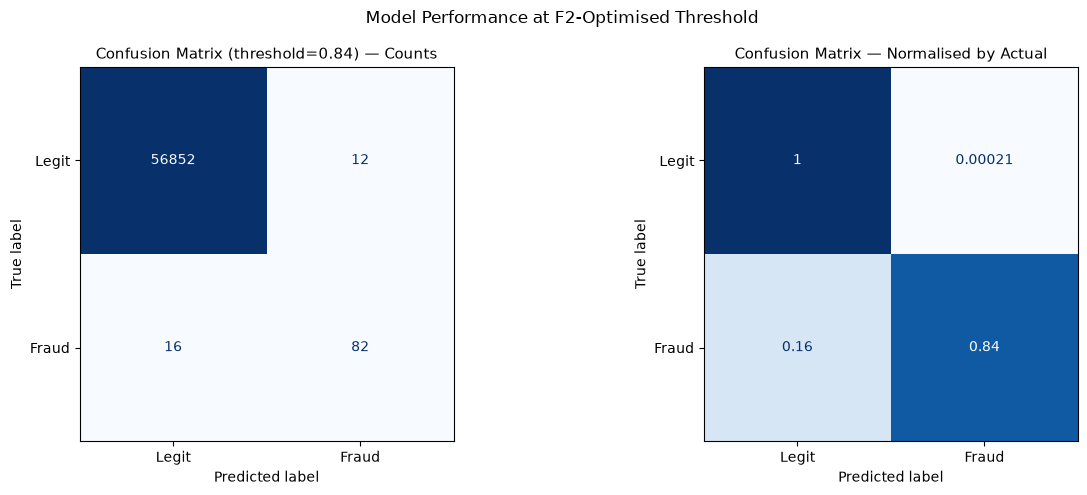


TP (caught fraud):      82
FN (missed fraud):      16
FP (blocked legit):     12
TN (cleared legit):     56,852

Fraud catch rate:       83.67%
False positive rate:    0.0211%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute counts
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix (threshold={THRESHOLD:.2f}) — Counts", fontsize=11)

# Normalized
cm_norm = confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="true")
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Legit", "Fraud"])
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Confusion Matrix — Normalised by Actual", fontsize=11)

plt.suptitle("Model Performance at F2-Optimised Threshold", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTP (caught fraud):      {tp:,}")
print(f"FN (missed fraud):      {fn:,}")
print(f"FP (blocked legit):     {fp:,}")
print(f"TN (cleared legit):     {tn:,}")
print(f"\nFraud catch rate:       {tp/(tp+fn):.2%}")
print(f"False positive rate:    {fp/(fp+tn):.4%}")


## 3. SHAP — global feature importance

SHAP (SHapley Additive exPlanations) provides a theoretically grounded, consistent attribution of each feature's contribution to every prediction. It answers: *which features drove this fraud score?*

In [6]:
print("Building SHAP explainer…")
X_train_sample = X_train.sample(n=min(300, len(X_train)), random_state=42)
explainer   = build_explainer(model, X_train_sample)

print(f"Computing SHAP values for {len(X_test):,} test transactions…")
shap_values = get_shap_values(explainer, X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("\nMean absolute SHAP by feature (global importance, top 10):")
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).nlargest(10)
print(mean_abs_shap.round(4).to_string())


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


Building SHAP explainer…
Computing SHAP values for 56,962 test transactions…


100%|===================| 56915/56962 [25:15<00:01]        

SHAP values shape: (56962, 36)

Mean absolute SHAP by feature (global importance, top 10):
V4           1.5768
V14          1.3554
V10_x_V14    1.1174
Time_cos     0.9273
Time_sin     0.7869
V10          0.7373
V11          0.6822
V12_x_V14    0.5973
V12          0.5938
V17          0.5632


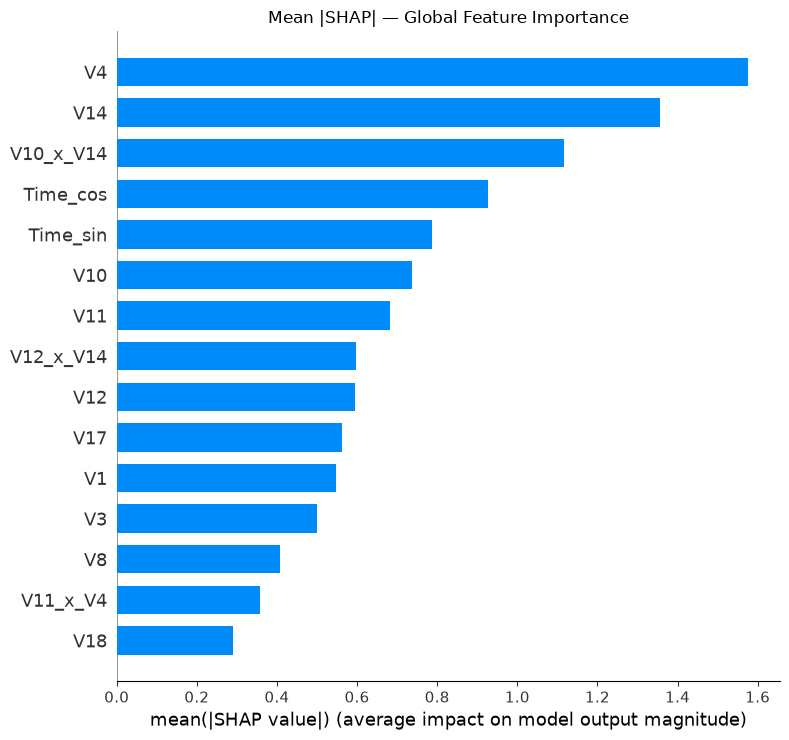

In [7]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("Mean |SHAP| — Global Feature Importance", fontsize=12)
plt.tight_layout()
plt.show()


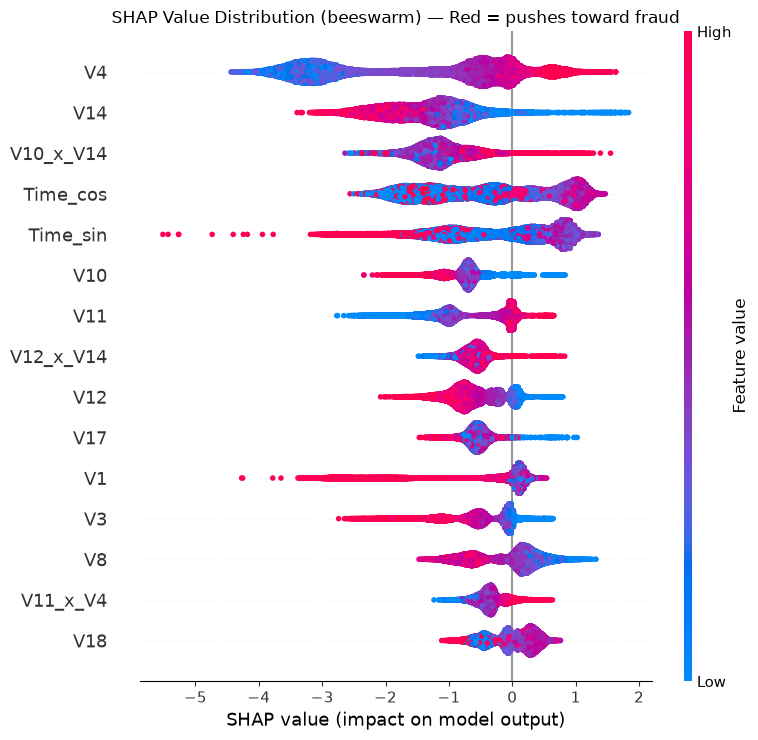

In [8]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Value Distribution (beeswarm) — Red = pushes toward fraud", fontsize=12)
plt.tight_layout()
plt.show()


## 4. SHAP waterfall — explaining a single fraud prediction

A waterfall plot shows how each feature pushed the model output from the base value (average prediction) to the final score for one transaction. This is what a fraud analyst sees when they investigate a flag.

In [9]:
# Find a confidently predicted fraud in the test set
fraud_indices = np.where((y_pred == 1) & (y_test.values == 1))[0]
if len(fraud_indices) == 0:
    fraud_indices = np.where(y_pred == 1)[0]

example_idx = fraud_indices[0]
X_example   = X_test.iloc[[example_idx]]
prob        = y_prob[example_idx]
actual      = y_test.iloc[example_idx]

print(f"Transaction index in test set: {example_idx}")
print(f"Fraud probability: {prob:.4f}")
print(f"Actual label:      {'FRAUD' if actual == 1 else 'LEGIT'}")
print(f"\nTop 3 SHAP features:")
for entry in top_k_features(shap_values[example_idx], feature_cols, k=3):
    direction = "▲ toward fraud" if entry['shap'] > 0 else "▼ toward legit"
    print(f"  {entry['feature']:<20}  SHAP={entry['shap']:+.4f}  {direction}")


Transaction index in test set: 840
Fraud probability: 0.9998
Actual label:      FRAUD

Top 3 SHAP features:
  V14                   SHAP=+1.4193  ▲ toward fraud
  V4                    SHAP=+1.0512  ▲ toward fraud
  V10_x_V14             SHAP=+0.8813  ▲ toward fraud


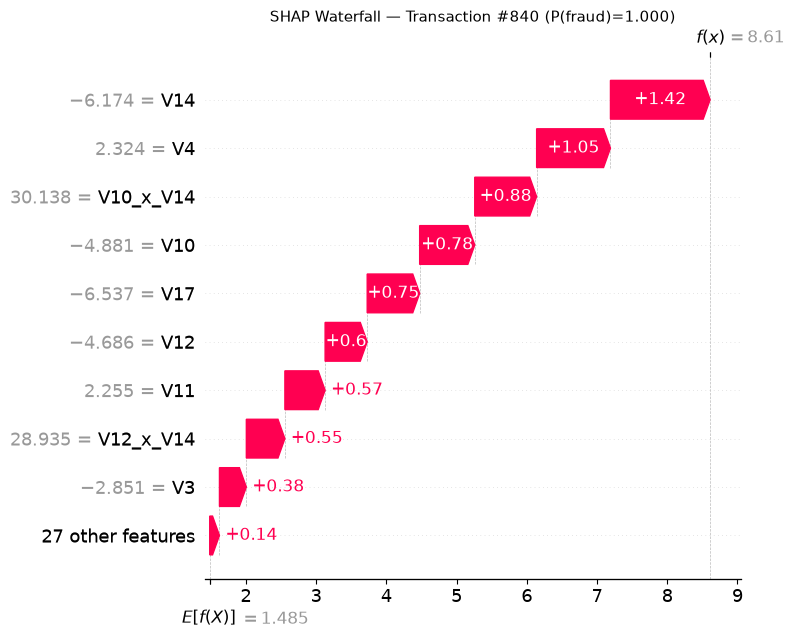

In [10]:
explanation = explainer(X_example)
if hasattr(explanation, 'values') and explanation.values.ndim == 3:
    shap_expl = shap.Explanation(
        values=explanation.values[0, :, 1],
        base_values=explanation.base_values[0, 1],
        data=explanation.data[0],
        feature_names=feature_cols,
    )
else:
    base = explanation.base_values[0] if np.ndim(explanation.base_values) > 0 else explanation.base_values
    shap_expl = shap.Explanation(
        values=explanation.values[0],
        base_values=base,
        data=explanation.data[0],
        feature_names=feature_cols,
    )

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_expl, show=False)
plt.title(f"SHAP Waterfall — Transaction #{example_idx} (P(fraud)={prob:.3f})", fontsize=11)
plt.tight_layout()
plt.show()


## 5. Business impact analysis

In [11]:
from model import sweep_thresholds, select_threshold

sweep_df = sweep_thresholds(y_test.values, y_prob, cost_fn=200.0, cost_fp=5.0)

best_05   = sweep_df[sweep_df["threshold"] == 0.50].iloc[0]
best_f2   = select_threshold(sweep_df, strategy="f2")
best_cost = select_threshold(sweep_df, strategy="cost")

print("Business impact comparison across threshold strategies")
print("="*65)
print(f"{'Strategy':<25} {'Threshold':>9} {'Caught %':>9} {'FP rate':>9} {'Cost €':>12}")
print("-"*65)

for label, row in [
    ("Default (0.50)", best_05),
    ("F2-optimised",   best_f2),
    ("Cost-optimised", best_cost),
]:
    cost_val = row["business_cost"] if hasattr(row, "__getitem__") else row.business_cost
    thresh   = row["threshold"]     if hasattr(row, "__getitem__") else row.threshold
    rec      = row["recall"]        if hasattr(row, "__getitem__") else row.recall
    fpr      = row["false_positive_rate"] if hasattr(row, "__getitem__") else row.false_positive_rate
    print(f"{label:<25} {thresh:>9.2f} {rec*100:>8.1f}% {fpr*100:>8.3f}% {cost_val:>12,.0f}")

print("="*65)
print(f"\nAssumptions: FN cost = €200/missed fraud | FP cost = €5/blocked tx")


Business impact comparison across threshold strategies
Strategy                  Threshold  Caught %   FP rate       Cost €
-----------------------------------------------------------------
Default (0.50)                 0.50     86.7%    0.086%        2,845
F2-optimised                   0.84     83.7%    0.021%        3,260
Cost-optimised                 0.42     88.8%    0.097%        2,475

Assumptions: FN cost = €200/missed fraud | FP cost = €5/blocked tx


## 6. Scored sample output

In [12]:
from explain import add_shap_explanations
import os

scored_path = "../outputs/scored_sample.csv"
if os.path.exists(scored_path):
    sample = pd.read_csv(scored_path)
    print(f"Loaded scored sample: {sample.shape}")
    sample[["fraud_probability", "risk_tier", "predicted_fraud", "actual_label",
            "shap_feature_1", "shap_value_1", "shap_feature_2", "shap_value_2"]].head(10)
else:
    print("Run pipeline.py first to generate scored_sample.csv")
    # Show what the output looks like with a small inline demo
    n_demo = min(20, len(X_test))
    demo_shap = shap_values[:n_demo]
    demo_X    = X_test.iloc[:n_demo].copy()
    demo_X["fraud_probability"] = y_prob[:n_demo]
    demo_X["risk_tier"] = ["HIGH" if p >= 0.65 else "MEDIUM" if p >= 0.35 else "LOW"
                           for p in y_prob[:n_demo]]
    demo_X["predicted_fraud"] = y_pred[:n_demo]
    demo_X["actual_label"]    = y_test.values[:n_demo]
    demo_out = add_shap_explanations(demo_X, demo_shap, feature_cols)
    demo_out[["fraud_probability", "risk_tier", "predicted_fraud", "actual_label",
              "shap_feature_1", "shap_value_1", "shap_feature_2", "shap_value_2"]].head(10)


Run pipeline.py first to generate scored_sample.csv


## 7. Summary

| Stage | Decision | Rationale |
|-------|----------|-----------|
| Metric | AUC-PR over AUC-ROC | Honest under 0.172% fraud rate |
| Imbalance | SMOTE + scale_pos_weight | Different mechanisms; complementary |
| Threshold | F2-optimised (not 0.5) | Recall matters more than precision in fraud |
| Explanations | SHAP per transaction | Fraud ops need a reason, not just a score |
| Scalability | PySpark preprocessing | Same code scales to 10–100× data |